In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from scipy.special import factorial

In [32]:
data = pd.read_csv("hist_week3_5ms.txt", sep='\t', header=0, names=["x", "y"],index_col=False)
data1 = pd.read_csv("hist_10ms.txt",sep='\t', header=0, names=["x", "y"])
data2 = pd.read_csv("hist_15ms.txt",sep='\t', header=0, names=["x", "y"])
data1['x'] = round(data1['x'])
data['x'] = round(data['x'])
data2['x'] = round(data2['x'])

In [18]:
data_470o = pd.read_csv("470o_5ms.txt", sep='\t', header=0, names=["x", "y"],index_col=False)
data_600o = pd.read_csv("600o_5ms.txt", sep='\t', header=0, names=["x", "y"],index_col=False)
data_760o = pd.read_csv("760o_5ms.txt", sep='\t', header=0, names=["x", "y"],index_col=False)
data_1ko = pd.read_csv("1ko_5ms.txt", sep='\t', header=0, names=["x", "y"],index_col=False)
data_2ko = pd.read_csv("2.2ko_5ms.txt", sep='\t', header=0, names=["x", "y"],index_col=False)
data_3ko = pd.read_csv("3.3ko_5ms.txt", sep='\t', header=0, names=["x", "y"],index_col=False)

Text(0, 0.5, 'Mean Count')

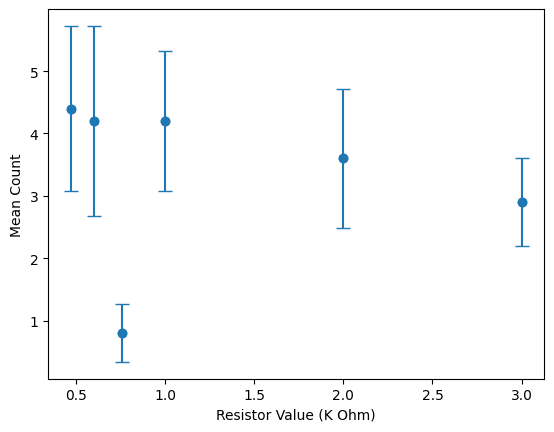

In [27]:
resistors = np.array([.470, .600, .760, 1, 2, 3])
counts = np.array([data_470o['y'].mean(), data_600o['y'].mean(), data_760o['y'].mean(), data_1ko['y'].mean(), data_2ko['y'].mean(), data_3ko['y'].mean()])
counts_std = np.array([data_470o['y'].std(), data_600o['y'].std(), data_760o['y'].std(), data_1ko['y'].std(), data_2ko['y'].std(), data_3ko['y'].std()])
plt.scatter(resistors, counts)
plt.errorbar(resistors, counts, yerr=counts_std/np.sqrt(len(counts)), fmt='o', capsize=5)
plt.xlabel('Resistor Value (K Ohm)')
plt.ylabel('Mean Count')

Text(0, 0.5, 'Mean Count')

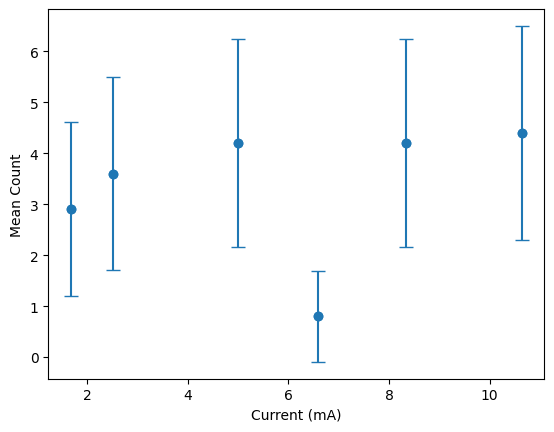

In [22]:
current = 5 / (resistors * 1000) * 1000 
plt.scatter(current, counts)
plt.errorbar(current, counts, yerr=np.sqrt(counts), fmt='o', capsize=5)
plt.xlabel('Current (mA)')
plt.ylabel('Mean Count')

Text(0, 0.5, 'Occurrencs (normed)')

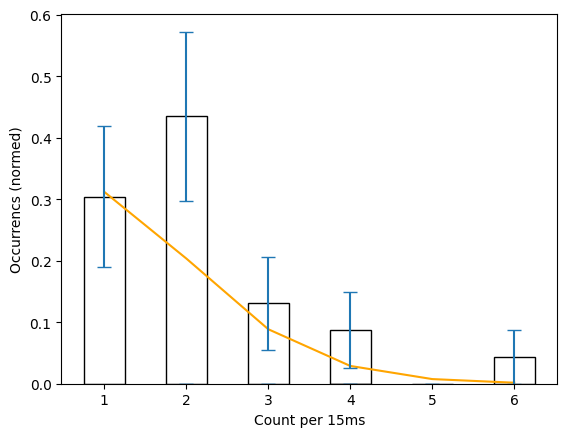

In [53]:
def poss(n,l,a):
    return (l*a)**n*np.exp(-l)/factorial(n)

params, _ = curve_fit(poss, data2["x"],data2["y"]/sum(data2["y"]))

plt.plot(data2["x"],poss(data2["x"],params[0],params[1]),color='orange')
plt.errorbar(data2["x"], data2["y"]/sum(data2["y"]), yerr=np.sqrt(data2["y"])/sum(data2["y"]),fmt='none',ecolor='tab:blue', capsize=5)
plt.bar(data2["x"], data2["y"]/sum(data2["y"]),align='center',edgecolor='black',width=0.5,color='white')
plt.xlabel("Count per 15ms")
plt.ylabel("Occurrencs (normed)")

Text(0, 0.5, 'Occurrencs (normed)')

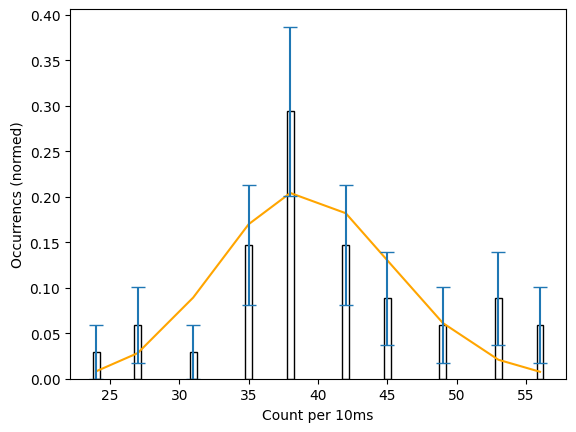

In [56]:
def poss(n,l,a):
    return (l*a)**n*np.exp(-l)/factorial(n)

data1=data

params, _ = curve_fit(poss, data1["x"],data1["y"]/sum(data1["y"]),p0=[40,1])

plt.plot(data1["x"],poss(data1["x"],params[0],params[1]),color='orange')
plt.errorbar(data1["x"], data1["y"]/sum(data1["y"]), yerr=np.sqrt(data1["y"])/sum(data1["y"]),fmt='none',ecolor='tab:blue', capsize=5)
plt.bar(data1["x"], data1["y"]/sum(data1["y"]),align='center',edgecolor='black',width=0.5,color='white')
plt.xlabel("Count per 10ms")
plt.ylabel("Occurrencs (normed)")